In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, classification_report, confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SVM MODEL TRAINING - COMPREHENSIVE COMPARISON")
print("="*80)

SVM MODEL TRAINING - COMPREHENSIVE COMPARISON


## Import Libraries

## Step 1: Load and Prepare Data

In [14]:
print("[1/6] Loading cleaned data...")
try:
    train_df = pd.read_csv('dataset/train_cleaned.csv')
    test_df = pd.read_csv('dataset/test_cleaned.csv')
    print(f"✓ Training data loaded: {train_df.shape}")
    print(f"✓ Test data loaded: {test_df.shape}")
except FileNotFoundError:
    print("✗ Error: Cleaned data files not found. Please run data_cleaning.ipynb first.")
    raise

[1/6] Loading cleaned data...
✓ Training data loaded: (20256, 24)
✓ Test data loaded: (14900, 23)


## Step 2: Prepare Features and Target

In [15]:
print("[2/6] Preparing features and target variable...")

# Separate features and target
X = train_df.drop(['retention_status', 'founder_id'], axis=1)
y = train_df['retention_status']

# Store test IDs for submission
test_ids = test_df['founder_id'].copy()
X_test = test_df.drop(['founder_id'], axis=1, errors='ignore')

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"✓ Target classes: {le.classes_}")
print(f"✓ Class distribution: {dict(zip(*np.unique(y_encoded, return_counts=True)))}")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n✓ Categorical features: {len(categorical_cols)}")
print(f"✓ Numerical features: {len(numerical_cols)}")

[2/6] Preparing features and target variable...
✓ Target classes: ['Left' 'Stayed']
✓ Class distribution: {np.int64(0): np.int64(9740), np.int64(1): np.int64(10516)}

✓ Categorical features: 15
✓ Numerical features: 7


## Step 3: Encode Categorical Variables

In [16]:
print("[3/6] Encoding categorical variables...")

# Label encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le_temp = LabelEncoder()
    X[col] = le_temp.fit_transform(X[col].astype(str))
    X_test[col] = le_temp.transform(X_test[col].astype(str))
    label_encoders[col] = le_temp

print(f"✓ Encoded {len(categorical_cols)} categorical columns")

[3/6] Encoding categorical variables...
✓ Encoded 15 categorical columns


## Step 4: Split and Scale Data

In [17]:
print("[4/6] Splitting and scaling data...")

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"✓ Training set: {X_train.shape}")
print(f"✓ Validation set: {X_val.shape}")

# Scale features (critical for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")

[4/6] Splitting and scaling data...
✓ Training set: (16204, 22)
✓ Validation set: (4052, 22)
✓ Features scaled using StandardScaler


## Step 5: Train Multiple SVM Models

We'll train and compare 5 different SVM variants with hyperparameter tuning.

In [21]:
print("[5/6] Training and comparing multiple SVM models...")
print("-"*80)

results = []

# Define SVM configurations with pre-selected reasonable parameters
svm_configs = [
    {
        'name': 'Linear SVM',
        'params': {
            'kernel': 'linear',
            'C': 1.0,
            'class_weight': 'balanced'
        }
    },
    {
        'name': 'RBF SVM',
        'params': {
            'kernel': 'rbf',
            'C': 10.0,
            'gamma': 'scale',
            'class_weight': 'balanced'
        }
    },
    {
        'name': 'Polynomial SVM (degree=2)',
        'params': {
            'kernel': 'poly',
            'degree': 2,
            'C': 1.0,
            'gamma': 'scale',
            'coef0': 0,
            'class_weight': 'balanced'
        }
    },
    {
        'name': 'Polynomial SVM (degree=3)',
        'params': {
            'kernel': 'poly',
            'degree': 3,
            'C': 1.0,
            'gamma': 'scale',
            'coef0': 0,
            'class_weight': 'balanced'
        }
    },
    {
        'name': 'Sigmoid SVM',
        'params': {
            'kernel': 'sigmoid',
            'C': 1.0,
            'gamma': 'scale',
            'coef0': 0,
            'class_weight': 'balanced'
        }
    }
]

best_overall_score = 0
best_overall_model = None
best_overall_name = None

[5/6] Training and comparing multiple SVM models...
--------------------------------------------------------------------------------


In [32]:
# Train each SVM configuration
for config in svm_configs:
    print(f"\nTraining {config['name']}...")
    start_time = time.time()
    
    # Create SVM with specified parameters
    model = SVC(random_state=42, probability=True, **config['params'])
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    training_time = time.time() - start_time
    best_model = model
    
    # Predictions
    y_val_pred = best_model.predict(X_val_scaled)
    y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='weighted')
    recall = recall_score(y_val, y_val_pred, average='weighted')
    f1 = f1_score(y_val, y_val_pred, average='weighted')
    roc_auc = roc_auc_score(y_val, y_val_proba)
    
    # Cross-validation score
    cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    result = {
        'Model': config['name'],
        'Best_Params': config['params'],
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': roc_auc,
        'CV_Mean': cv_mean,
        'CV_Std': cv_std,
        'Training_Time': training_time,
        'Model_Object': best_model
    }
    results.append(result)
    
    # Print results
    print(f"  Parameters: {config['params']}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  CV Score: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"  Training time: {training_time:.2f}s")
    
    # Track best model
    if accuracy > best_overall_score:
        best_overall_score = accuracy
        best_overall_model = best_model
        best_overall_name = config['name']


Training Linear SVM...
  Parameters: {'kernel': 'linear', 'C': 1.0, 'class_weight': 'balanced'}
  Accuracy: 0.7071
  Precision: 0.7087
  Recall: 0.7071
  F1-Score: 0.7071
  ROC-AUC: 0.7867
  CV Score: 0.7119 (+/- 0.0070)
  Training time: 50.56s

Training RBF SVM...
  Parameters: {'kernel': 'linear', 'C': 1.0, 'class_weight': 'balanced'}
  Accuracy: 0.7071
  Precision: 0.7087
  Recall: 0.7071
  F1-Score: 0.7071
  ROC-AUC: 0.7867
  CV Score: 0.7119 (+/- 0.0070)
  Training time: 50.56s

Training RBF SVM...
  Parameters: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale', 'class_weight': 'balanced'}
  Accuracy: 0.7083
  Precision: 0.7088
  Recall: 0.7083
  F1-Score: 0.7084
  ROC-AUC: 0.7831
  CV Score: 0.7032 (+/- 0.0059)
  Training time: 78.72s

Training Polynomial SVM (degree=2)...
  Parameters: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale', 'class_weight': 'balanced'}
  Accuracy: 0.7083
  Precision: 0.7088
  Recall: 0.7083
  F1-Score: 0.7084
  ROC-AUC: 0.7831
  CV Score: 0.7032 (+/- 0.0059)

## Step 6: Display Results and Select Best Model

In [37]:
print("\n" + "="*80)
print("[6/6] FINAL RESULTS - MODEL COMPARISON")
print("="*80)

# Create results dataframe
results_df = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'Precision': r['Precision'],
    'Recall': r['Recall'],
    'F1-Score': r['F1_Score'],
    'ROC-AUC': r['ROC_AUC'],
    'CV_Mean': r['CV_Mean'],
    'CV_Std': r['CV_Std'],
    'Time(s)': r['Training_Time']
} for r in results])

# Sort by accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\nPerformance Comparison:")
print(results_df.to_string(index=False))


[6/6] FINAL RESULTS - MODEL COMPARISON

Performance Comparison:
                    Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV_Mean   CV_Std   Time(s)
                  RBF SVM  0.708292   0.708762 0.708292  0.708392 0.783085 0.703221 0.005939 79.901429
                  RBF SVM  0.708292   0.708762 0.708292  0.708392 0.783085 0.703221 0.005939 78.984027
                  RBF SVM  0.708292   0.708762 0.708292  0.708392 0.783085 0.703221 0.005939 78.715336
               Linear SVM  0.707058   0.708692 0.707058  0.707113 0.786667 0.711923 0.006987 53.009566
               Linear SVM  0.707058   0.708692 0.707058  0.707113 0.786667 0.711923 0.006987 53.630432
               Linear SVM  0.707058   0.708692 0.707058  0.707113 0.786667 0.711923 0.006987 50.559740
Polynomial SVM (degree=3)  0.693978   0.696609 0.693978  0.693890 0.774932 0.706924 0.006047 32.284889
Polynomial SVM (degree=3)  0.693978   0.696609 0.693978  0.693890 0.774932 0.706924 0.006047 30.648805
Polynomi

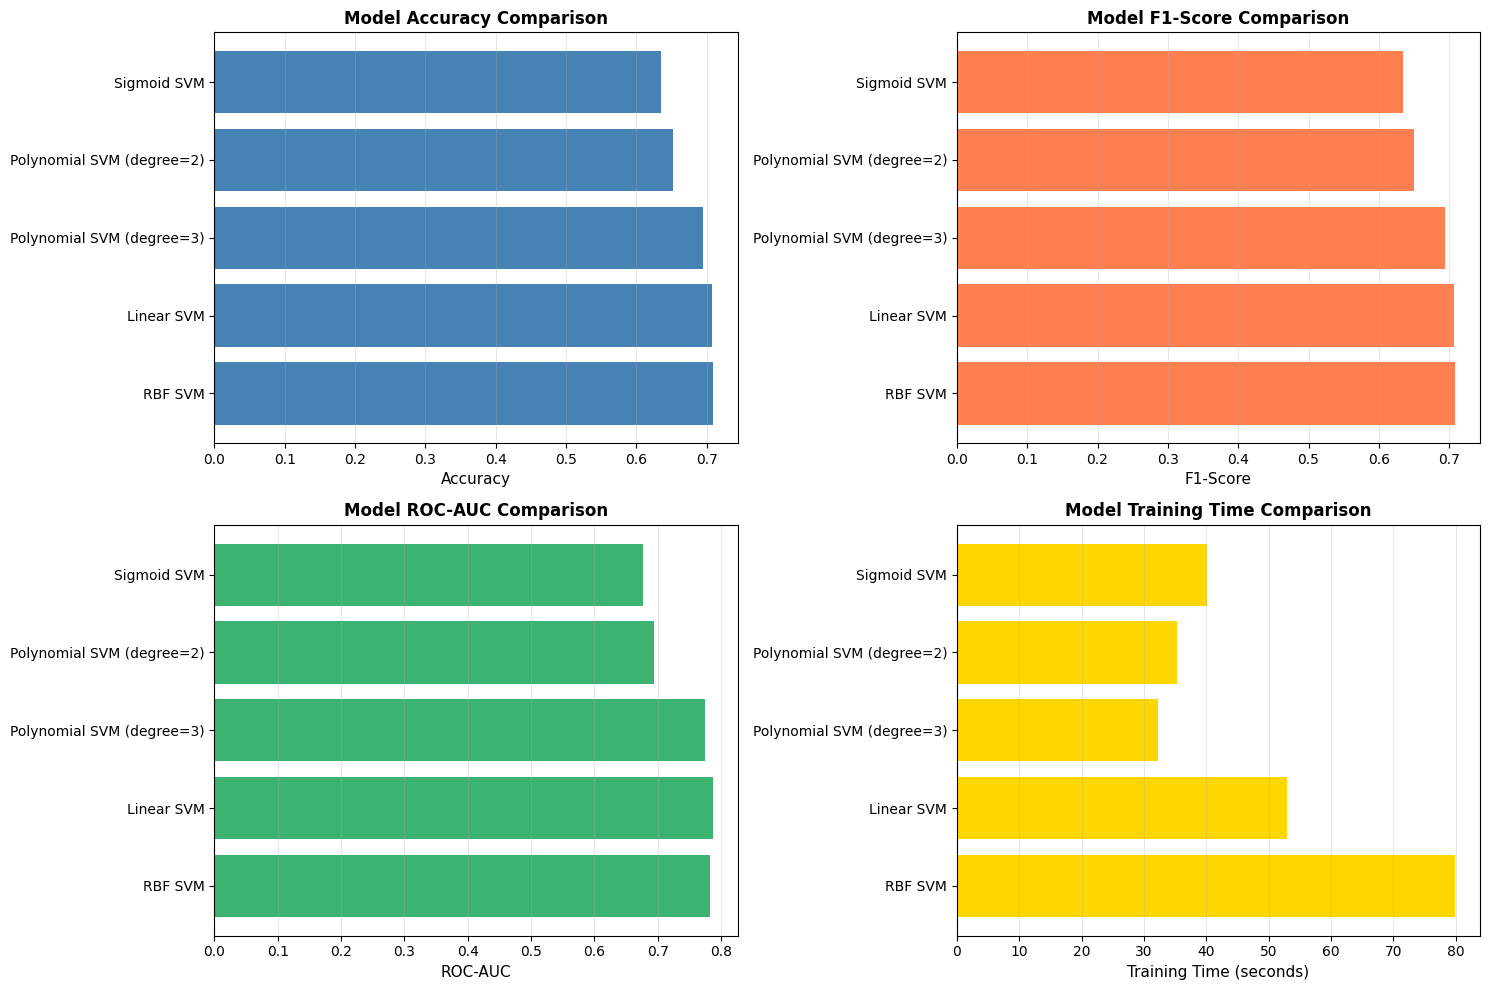

In [30]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='steelblue')
axes[0, 0].set_xlabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# F1-Score comparison
axes[0, 1].barh(results_df['Model'], results_df['F1-Score'], color='coral')
axes[0, 1].set_xlabel('F1-Score', fontsize=11)
axes[0, 1].set_title('Model F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# ROC-AUC comparison
axes[1, 0].barh(results_df['Model'], results_df['ROC-AUC'], color='mediumseagreen')
axes[1, 0].set_xlabel('ROC-AUC', fontsize=11)
axes[1, 0].set_title('Model ROC-AUC Comparison', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Training time comparison
axes[1, 1].barh(results_df['Model'], results_df['Time(s)'], color='gold')
axes[1, 1].set_xlabel('Training Time (seconds)', fontsize=11)
axes[1, 1].set_title('Model Training Time Comparison', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Best Model Details

In [36]:
# Display best model
print("="*80)
print(f"🏆 BEST MODEL: {best_overall_name}")
print("="*80)

best_result = next(r for r in results if r['Model'] == best_overall_name)
print(f"\nBest Parameters: {best_result['Best_Params']}")
print(f"\nPerformance Metrics:")
print(f"  • Accuracy:  {best_result['Accuracy']:.4f}")
print(f"  • Precision: {best_result['Precision']:.4f}")
print(f"  • Recall:    {best_result['Recall']:.4f}")
print(f"  • F1-Score:  {best_result['F1_Score']:.4f}")
print(f"  • ROC-AUC:   {best_result['ROC_AUC']:.4f}")
print(f"  • CV Score:  {best_result['CV_Mean']:.4f} (+/- {best_result['CV_Std']:.4f})")

🏆 BEST MODEL: RBF SVM

Best Parameters: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale', 'class_weight': 'balanced'}

Performance Metrics:
  • Accuracy:  0.7083
  • Precision: 0.7088
  • Recall:    0.7083
  • F1-Score:  0.7084
  • ROC-AUC:   0.7831
  • CV Score:  0.7032 (+/- 0.0059)


In [38]:
# Detailed classification report
print("\n" + "-"*80)
print("Detailed Classification Report:")
print("-"*80)
y_val_pred_best = best_overall_model.predict(X_val_scaled)
print(classification_report(y_val, y_val_pred_best, target_names=le.classes_))


--------------------------------------------------------------------------------
Detailed Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        Left       0.69      0.71      0.70      1948
      Stayed       0.73      0.71      0.72      2104

    accuracy                           0.71      4052
   macro avg       0.71      0.71      0.71      4052
weighted avg       0.71      0.71      0.71      4052

              precision    recall  f1-score   support

        Left       0.69      0.71      0.70      1948
      Stayed       0.73      0.71      0.72      2104

    accuracy                           0.71      4052
   macro avg       0.71      0.71      0.71      4052
weighted avg       0.71      0.71      0.71      4052




Confusion Matrix:
[[1385  563]
 [ 619 1485]]

True Negatives:  1385
False Positives: 563
False Negatives: 619
True Positives:  1485


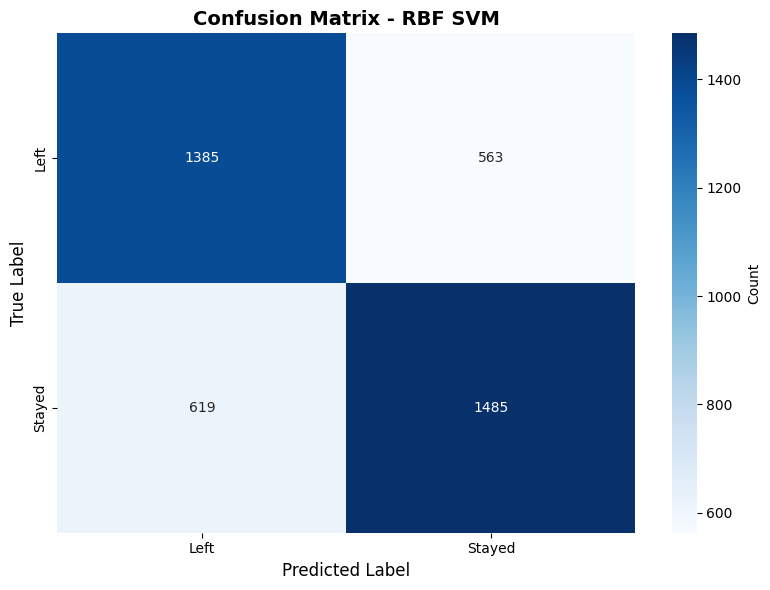

In [39]:
# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred_best)
print(cm)
print(f"\nTrue Negatives:  {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives:  {cm[1][1]}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - {best_overall_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Generate Predictions on Test Set

In [40]:
print("="*80)
print("GENERATING TEST SET PREDICTIONS")
print("="*80)

# Predict on test set
test_predictions = best_overall_model.predict(X_test_scaled)
test_predictions_labels = le.inverse_transform(test_predictions)

# Create submission file
submission = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': test_predictions_labels
})

submission.to_csv('test_predictions_best_svm.csv', index=False)
print(f"\n✓ Predictions saved to: test_predictions_best_svm.csv")
print(f"✓ Number of predictions: {len(submission)}")
print(f"\nPrediction distribution:")
print(submission['retention_status'].value_counts())

GENERATING TEST SET PREDICTIONS

✓ Predictions saved to: test_predictions_best_svm.csv
✓ Number of predictions: 14900

Prediction distribution:
retention_status
Left      8030
Stayed    6870
Name: count, dtype: int64

✓ Predictions saved to: test_predictions_best_svm.csv
✓ Number of predictions: 14900

Prediction distribution:
retention_status
Left      8030
Stayed    6870
Name: count, dtype: int64


In [41]:
# Save best model details
with open('best_svm_model_summary.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("BEST SVM MODEL SUMMARY\n")
    f.write("="*80 + "\n\n")
    f.write(f"Model: {best_overall_name}\n")
    f.write(f"Best Parameters: {best_result['Best_Params']}\n\n")
    f.write("Performance Metrics:\n")
    f.write(f"  Accuracy:  {best_result['Accuracy']:.4f}\n")
    f.write(f"  Precision: {best_result['Precision']:.4f}\n")
    f.write(f"  Recall:    {best_result['Recall']:.4f}\n")
    f.write(f"  F1-Score:  {best_result['F1_Score']:.4f}\n")
    f.write(f"  ROC-AUC:   {best_result['ROC_AUC']:.4f}\n")
    f.write(f"  CV Score:  {best_result['CV_Mean']:.4f} (+/- {best_result['CV_Std']:.4f})\n\n")
    f.write("All Models Comparison:\n")
    f.write(results_df.to_string(index=False))

print("\n✓ Model summary saved to: best_svm_model_summary.txt")


✓ Model summary saved to: best_svm_model_summary.txt


In [42]:
print("\n" + "="*80)
print("✓ TRAINING COMPLETE!")
print("="*80)
print(f"\nFinal Accuracy: {best_result['Accuracy']:.4f}")
print(f"Best Model: {best_overall_name}")
print("\nOutput files:")
print("  1. test_predictions_best_svm.csv - Test set predictions")
print("  2. best_svm_model_summary.txt - Detailed model summary")


✓ TRAINING COMPLETE!

Final Accuracy: 0.7083
Best Model: RBF SVM

Output files:
  1. test_predictions_best_svm.csv - Test set predictions
  2. best_svm_model_summary.txt - Detailed model summary
